## PatchTST - A Transformer Architecture for long-term forecasting for time-series

Dieses Notebook erklärt die Architektur und Anwendung von **PatchTST**.
**PatchTST** eignet sich gut für die Langfristige Vorhersage von multivariaten Zeitreihen.


Zunächst wird die Architektur des Modells erklärt, dazu beziehen wir uns auf die Architektur aus dem Originalpaper.

Unser Modell hebt sich durch zwei Konzepte von vorangegangenen Modellen ab:

Das Konzept des **Patching** bedeutet, dass Teilsequenzen der Zeitreihe betrachtet werden, wodurch die zeitabhängigen Features bewahrt werden. Frühere Modelle haben einzelne Punkte betrachtet und die Eigenschaften einer Zeitreihe nicht beachtet.

Das Konzept **Channel-Independence**  ist eine Strategie für multivariate Zeitreihen, bei der multivariate Zeitreihen so aufgeteilt werden, dass jede Variable als eine eigene, unabhängige univariate Zeitreihe behandelt wird.

Die Reihenfolge orientiert sich am **CRISP-DM-Modell**:

1. Geschäftsverständnis
2. Datenverständnis
3. Datenvorbereitung
4. Modeling
5. Evaluation
6. Deployment

Wichtig: CRISP-DM ist kein einmaliger Durchlauf. Feedback aus der Evaluation oder aus dem Fachbereich kann dazu führen, dass wir eine weitere Iteration starten und Annahmen, Daten oder Modellierung anpassen.

## PatchTST - Modell Architektur und Erläuterung der einzelnen Schichten


In [1]:
# Import von Tensorflow
import tensorflow as tf
tf.config.run_functions_eagerly(True)
from tensorflow.keras import layers

In [2]:
import numpy as np
np.random.seed(42) # Wiederholbare Ergebnisse erzeugen.

Die Embedding Schicht unseres Modells:

Striktes Channel-Independence - dies unterscheidet unser Modell zu den Vorgängern.

In [3]:
class PatchTSTEmbedding(layers.Layer):
    def __init__(self, patch_len, stride, d_model):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.proj = layers.Dense(d_model)

    def call(self, x):
        # x Form: (batch, seq_len, channels)
        batch = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        channels = tf.shape(x)[2]

        # 1. Striktes Channel-Independence: Kanäle in die Batch-Dimension verschieben
        # Neuen Form: (batch, channels, seq_len)
        x = tf.transpose(x, perm=[0, 2, 1])
        # Zusammenfassen zu: (batch * channels, seq_len)
        x = tf.reshape(x, (batch * channels, seq_len))

        # 2. Extraktion der Patches mit Stride (Überlappung) mithilfe von Slicing oder tf.signal
        # (Zur Vereinfachung hier via Slicing für überlappende Fenster)
        num_patches = (seq_len - self.patch_len) // self.stride + 1
        
        patches = []
        for i in range(num_patches):
            start = i * self.stride
            end = start + self.patch_len
            patches.append(x[:, start:end])
        
        # Form nach Stack: (num_patches, batch * channels, patch_len)
        x = tf.stack(patches, axis=0)
        # Umformen zu: (batch * channels, num_patches, patch_len)
        x = tf.transpose(x, perm=[1, 0, 2])

        # 3. Lineare Projektion auf die Transformer-Dimension d_model
        # Jedes univariate Patch wird jetzt projiziert
        return self.proj(x)  # Ausgabeform: (batch * channels, num_patche

Die Positional Encoding Schicht stellt sicher, dass die Eigenschaften der Zeitreihe und erhalten bleiben.

In [4]:
class PatchTSTPositionalEncoding(layers.Layer):
    def __init__(self, num_patches, d_model):
        super().__init__()
        # Lernbare Gewichte für die Positionen: (Num_Patches, d_model)
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(num_patches, d_model),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True
        )

    def call(self, x):
        # x Form: (Batch * Channels, Num_Patches, d_model)
        # Dank Broadcasting wird das (Num_Patches, d_model) Embedding 
        # automatisch auf alle (Batch * Channels) addiert.
        return x + self.pos_embed

###### OLD: Positional Embedding umd die Spezifika der Zeitreihe zu erhalten, dass nahegelegene Zeitpunkte zusammen gehören.

class PositionalEmbedding(layers.Layer):
    def __init__(self, max_patches, d_model):
        super().__init__()

        self.embedding = self.add_weight(
            shape=(1, max_patches, d_model),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        return x + self.embedding[:, :tf.shape(x)[1], :]


Die TransformerSchicht unseres Modells besteht aus den folgenden Schichten:

1. Multi-Head Attention (MHA)Funktion: Berechnet die Beziehungen (Attention) der Patches untereinander innerhalb eines einzelnen Kanals.Besonderheit: Da PatchTST jeden Kanal als eigenen Batch behandelt (Channel Independence), sieht die Attention-Schicht keine Korrelationen zwischen verschiedenen Kanälen. Sie fokussiert sich rein auf die zeitliche Struktur (Semantik) innerhalb der Patches einer Zeitreihe.

2. Layer Normalization & Residual ConnectionsAufbau: Wie im klassischen Transformer (oft als Pre-LN implementiert) wird vor der Attention-Schicht eine Layer Normalization angewendet.
Residuals: Das ursprüngliche Patch-Signal wird per Shortcut-Verbindung (Add) nach der Attention wieder hinzugerechnet, um den Gradientenfluss in tiefen Netzen stabil zu halten.

3. Feed-Forward Network (FFN / MLP)Aufbau: Besteht aus zwei linearen Schichten mit einer nicht-linearen Aktivierungsfunktion GELU dazwischen.

Dimensionen: Projiziert die Vektoren der Patches von der Modell-Dimension (d_model=128) hoch in eine tiefere Repräsentationsdimension (mlp_dim=256) und spiegelt sie anschließend wieder auf d_model zurück.

4. Zweite Layer Normalization & Residual Connection: Schließt den Layer ab, normiert die Ausgaben des Feed-Forward-Netzwerks und addiert das Signal vor dem FFN-Block, bevor die Daten an den nächsten Transformer-Layer (oder den Forecasting-Head) weitergereicht werden.

In [5]:
class PatchTSTTransformerBlock(layers.Layer):
    def __init__(self, d_model, n_heads, dimPT, dropout=0.1):
        super().__init__()
        # Multi-Head Attention Komponente
        self.mha = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads)
        
        # Position-wise Feed-Forward Network (FFN) mit GELU
        self.ffn = tf.keras.Sequential([
            layers.Dense(dimPT, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(d_model)
        ])
        
        # Layer Normalization (Pre-LN Struktur)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-5)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-5)
        
        # Dropout für die Residuen-Verbindungen
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        # x Form: (Batch * Channels, Num_Patches, d_model)
        
        # 1. Erster Block: Pre-LN -> Attention -> Dropout -> Residual-Addition
        norm_x1 = self.layernorm1(x)
        attn_output = self.mha(query=norm_x1, value=norm_x1, key=norm_x1, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        x = x + attn_output
        
        # 2. Zweiter Block: Pre-LN -> FFN -> Dropout -> Residual-Addition
        norm_x2 = self.layernorm2(x)
        ffn_output = self.ffn(norm_x2, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        x = x + ffn_output
        
        return x  # Ausgabe-Form bleibt: (Batch * Channels, Num_Patches, d_model)


Die Flatten Head Schicht, ist für die Vorhersagen unseres Prediction Modells verantwortlich

In [6]:
class PatchTSTFlattenHead(layers.Layer):
    def __init__(self, num_patches, d_model, pred_len):
        super().__init__()
        self.pred_len = pred_len
        
        # Lineare Schicht zur Vorhersage der zukünftigen Werte
        # Input-Größe implizit: num_patches * d_model
        self.flatten = layers.Flatten()
        self.linear = layers.Dense(pred_len)

    def call(self, x, batch_size, num_channels):
        # x Form beim Eingang: (Batch * Channels, Num_Patches, d_model)
        
        # 1. Abflachen: (Batch * Channels, Num_Patches * d_model)
        x = self.flatten(x)
        
        # 2. Lineare Projektion auf den Vorhersage-Horizont: (Batch * Channels, pred_len)
        x = self.linear(x)
        
        # 3. Zurückfalten in die originale Kanal-Struktur:
        # Erst trennen: (Batch, Channels, pred_len)
        x = tf.reshape(x, (batch_size, num_channels, self.pred_len))
        
        # Dimensionen zurücktauschen zu: (Batch, pred_len, Channels)
        x = tf.transpose(x, perm=[0, 2, 1])
        
        return x

### Das finale PatchTSTSelfSupervised Modell

Aufbau:
- PatchTSTEmbedding Schicht
- PatchTSTPositionalEncoding Schicht
- PatchTSTTransformer Schichten
- Fully Connected Layer Schicht

Die Fully Connected Layer Schicht unterscheidet das PatchTSTSElfSupervised Modell vom PatchTST Vorhersagemodell, welches weiter unten erstellt wird.


In [7]:
#Selfsupervised PatchTST erstellen und Schichten zusammenbauen
class PatchTSTSelfSuper(tf.keras.Model):

    def __init__(
            self,
            seq_len,
            patch_len,
            stride,
            d_model,
            depth,
            heads,
            mlp_dim,
            num_channels):

        super().__init__()

        self.patch_len = patch_len
        self.channels = num_channels

         # Berechnen der exakten Patch-Anzahl vorab
        self.num_patches = (seq_len - patch_len) // stride + 1

        self.patch_embed = PatchTSTEmbedding(
            patch_len,
            stride,
            d_model
        )

        self.position = PatchTSTPositionalEncoding(num_patches=self.num_patches, d_model=d_model)
        

        self.encoder = [
            PatchTSTTransformerBlock(
                d_model,
                heads, 
                mlp_dim
                )
                for _ in range(depth)
                ]
    

        # Reconstruction Head
        self.head = layers.Dense(
            patch_len * num_channels
        )

    def call(self, x):
        #if training is None:
        #   training = False

        x = self.patch_embed(x)

        x = self.position(x)

        for block in self.encoder:
            x=block(x)
            #x = block(x, training)

        x = self.head(x)

        return x


### Das finale PatchTST Vorhersage Modell

Aufbau:
- PatchTSTEmbedding Schicht
- PatchTSTPositionalEncoding Schicht
- PatchTSTTransformer Schichten
- Flatten Head Schicht

Kurz notiert, das PatchTST Vorhersagemodell hat eine Flatten Head Schicht um Vorhersagen treffen zu können.

In [8]:
class PatchTSTModel(tf.keras.Model):
    def __init__(self, seq_len, patch_len, stride, d_model, heads, mlp_dim, depth, num_channels, pred_len):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        
        # Berechnen der exakten Patch-Anzahl vorab
        self.num_patches = (seq_len - patch_len) // stride + 1
        
        # Schichten initialisieren
        self.embedding = PatchTSTEmbedding(patch_len=patch_len, stride=stride, d_model=d_model)
        self.pos_encoding = PatchTSTPositionalEncoding(num_patches=self.num_patches, d_model=d_model)
        
        self.encoder_layers = [
            PatchTSTTransformerBlock(d_model, heads, mlp_dim) 
            for _ in range(depth)
        ]
        
        self.head = PatchTSTFlattenHead(num_patches=self.num_patches, d_model=d_model, pred_len=pred_len)

    def call(self, inputs, training=False):
        # inputs Form: (Batch, seq_len, Channels)
        batch_size = tf.shape(inputs)[0]
        num_channels = tf.shape(inputs)[2]
        
        # 1. Patching & Embedding -> (Batch * Channels, Num_Patches, d_model)
        x = self.embedding(inputs)
        
        # 2. Positional Encoding addieren
        x = self.pos_encoding(x)
        
        # 3. Durch die Transformer-Blöcke schleifen
        for transformer_block in self.encoder_layers:
            x = transformer_block(x, training=training)
            
        # 4. Flatten-Head: Zurückrechnen auf die Ziel-Kanäle -> (Batch, pred_len, Channels)
        outputs = self.head(x, batch_size=batch_size, num_channels=num_channels)
        
        return outputs

### Testen des PatchTST Vorhersage Modell

In [9]:
#Testen
# Modell erstellen

seq_len = 512 
channels = 3


model = PatchTSTModel(
    seq_len=seq_len,
    patch_len=16,
    stride=128,
    d_model=128,
    heads=8,
    mlp_dim=256,
    depth=6, 
    num_channels=3,
    pred_len=512
)

dummy = tf.random.normal(shape=(8, seq_len, 3),dtype=float)

#Prüfen, welche Größe das PatchTST Modell im Ausgabelayer hat:
out = model(dummy)
print(out.shape)


# Falls die Folgenden Zeilen zum Troubleshooting verwendet werden, bitte die Eagerfunktion
# zu Beginn des Notebooks aktivieren. 
#try:
  #  out = model(dummy)
    #Prüfen welche Größe unser Modell im Ausgabelayer hat:
   # print(out.shape)

#except Exception as e:
 #   print("--- FEHLER GEFUNDEN ---")
 #   if hasattr(e, 'eager_backend_error'):
 #       print(e.eager_backend_error)
 #   else:
 #       # In welcher spezifischen Schicht tritt der Fehler auf?
 #       import traceback
 #       traceback.print_exc() 



#







(8, 512, 3)


##### Hyperparameter definieren und Synthetische Testdaten für einen kurzen Test des Prediction-Modells erstellen.

Schritt 1: Hyperparameter definieren

In [10]:
import warnings

BATCH_SIZE = 16
SEQ_LEN = 512      # Historische Schauzeit (Lookback-Window)
CHANNELS = 3       # Anzahl paralleler Features/Variablen (z.B. Wetterdaten)
PRED_LEN = 96      # Vorhersagehorizont (Zukunft)

PATCH_LEN = 16     # Länge eines einzelnen Patches
STRIDE = 8         # Schrittweite (50% Überlappung)
D_MODEL = 128      # Transformer Embedding-Dimension
N_HEADS = 4        # Multi-Head Attention Köpfe
D_FF = 256         # Feed-Forward Dimension im Transformer
NUM_LAYERS = 3     # Anzahl der Transformer-Blöcke

Schritt 2: Synthetische Trainingsdaten generieren und skalieren

In [11]:

# Leicht gestörte Sinus- und Cosinus-Wellen für realistische Tests
np.random.seed(42)

time_steps = np.linspace(0, 50, BATCH_SIZE * (SEQ_LEN + PRED_LEN))

signal_c1 = np.sin(time_steps)
signal_c2 = np.cos(time_steps * 0.5)
signal_c3 = np.sin(time_steps * 2.0) + np.cos(time_steps)

all_data = np.stack([signal_c1, signal_c2, signal_c3], axis=-1)
all_data += np.random.normal(0, 0.1, all_data.shape)

# Skalierung pro Kanal

# Mittelwert (Mean) und Standardabweichung (Std) pro Kanal berechnen
# axis=0 sorgt dafür, dass jeder der 3 Kanäle unabhängig skaliert wird
means = np.mean(all_data, axis=0)
stds = np.std(all_data, axis=0)

# Sicherheitsnetz: Verhindert Division durch Null bei konstanten Signalen
stds = np.where(stds == 0, 1.0, stds)

# Daten transformieren (Mittelwert = 0, Standardabweichung = 1)
time_data_scaled = (all_data - means) / stds

Schritt 3: Batch- Aufteilung nachdem die Daten skaliert sind und Train-Daten vorbereiten

In [12]:
X_train = []
Y_train = []

for i in range(BATCH_SIZE):
    start_idx = i * 10  # Versetzte Fenster simulieren
    # PatchTST erhält die skalierten Werte
    X_train.append(time_data_scaled[start_idx : start_idx + SEQ_LEN])
    Y_train.append(time_data_scaled[start_idx + SEQ_LEN : start_idx + SEQ_LEN + PRED_LEN])

X_train = np.array(X_train, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.float32)

print("--- DATEN-Dimensionen prüfen ---")
print(f"X_train (Inputs):  {X_train.shape} -> (Batch, Seq_Len, Channels)")
print(f"Y_train (Targets): {Y_train.shape}  -> (Batch, Pred_Len, Channels)\n")

--- DATEN-Dimensionen prüfen ---
X_train (Inputs):  (16, 512, 3) -> (Batch, Seq_Len, Channels)
Y_train (Targets): (16, 96, 3)  -> (Batch, Pred_Len, Channels)



Schritt 4: Die Schritte 2 und 3 diesmal für die Validierungsdaten.

In [13]:
# Wir setzen die Zeitachse fort (z.B. von 50 bis 100), um echte Zukunftsdaten zu simulieren
time_steps_val = np.linspace(50, 100, BATCH_SIZE * (SEQ_LEN + PRED_LEN))
signal_val_c1 = np.sin(time_steps_val)
signal_val_c2 = np.cos(time_steps_val * 0.5)
signal_val_c3 = np.sin(time_steps_val * 2.0) + np.cos(time_steps_val)

all_val_data = np.stack([signal_val_c1, signal_val_c2, signal_val_c3], axis=-1)
all_val_data += np.random.normal(0, 0.1, all_val_data.shape)

# Skalierung
# Mittelwert (Mean) und Standardabweichung (Std) pro Kanal berechnen
# axis=0 sorgt dafür, dass jeder der 3 Kanäle unabhängig skaliert wird
means_val = np.mean(all_data, axis=0)
stds_val = np.std(all_data, axis=0)

# Sicherheitsnetz: Verhindert Division durch Null bei konstanten Signalen
stds = np.where(stds == 0, 1.0, stds)

# Daten transformieren (Mittelwert = 0, Standardabweichung = 1)
time_data_val_scaled = (all_val_data - means_val) / stds_val

# 3. FENSTER-AUFTEILUNG mit skalierten Daten)
# =====================================================================
X_val, Y_val= [], []

for i in range(BATCH_SIZE):
    start_idx = i * 10  # Versetzte Fenster simulieren
    # PatchTST erhält die skalierten Werte
    X_val.append(time_data_val_scaled[start_idx : start_idx + SEQ_LEN])
    Y_val.append(time_data_val_scaled[start_idx + SEQ_LEN : start_idx + SEQ_LEN + PRED_LEN])

X_val = np.array(X_val, dtype=np.float32)
Y_val = np.array(Y_val, dtype=np.float32)



print("-- Validierungsdaten-Dimensionen prüfen ")
print(f"X_val (Inputs):  {X_val.shape} -> (Batch, Seq_Len, Channels)")
print(f"Y_val (Targets): {Y_val.shape}  -> (Batch, Pred_Len, Channels)\n")

-- Validierungsdaten-Dimensionen prüfen 
X_val (Inputs):  (16, 512, 3) -> (Batch, Seq_Len, Channels)
Y_val (Targets): (16, 96, 3)  -> (Batch, Pred_Len, Channels)



Schritt 5: Vorhersage-PatchTST-Modell instanziieren und testen

In [14]:
# Instanziierung des zuvor definierten Gesamtmodells
model = PatchTSTModel(
    seq_len=SEQ_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    heads=N_HEADS,
    mlp_dim=D_FF,
    depth=NUM_LAYERS,
    num_channels=CHANNELS,
    pred_len=PRED_LEN
)

# Test-Vorhersage ohne Training (Forward Pass)
predictions = model(X_train, training=False)

print("--- Dimension des Ausgabelayers prüfen: ---")
print(f"Dimension des Ausgabenlayer:     {predictions.shape} -> Sollte exakt Y_train entsprechen!\n")


--- Dimension des Ausgabelayers prüfen: ---
Dimension des Ausgabenlayer:     (16, 96, 3) -> Sollte exakt Y_train entsprechen!



Schritt 6: MODELL wird Kompiliert und nutzt hierbei den Optimizer ADAM und die Lossfunktion MSE

In [15]:
# 4. MODELL wird Kompiliert und nutzt hierbei den Optimizer ADAM und die Lossfunktion MSE
# =====================================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)
# 5. Kurzes Probetraining mit 7 Durchläufen
# =====================================================================
warnings.filterwarnings("ignore")
print("--- TRAININGSTEST mit Synthetischen Daten über 100 Durchläufe---")
#Kurzer Test-Lauf, um zu sehen, ob Backpropagation fehlerfrei läuft
history = model.fit(X_train, Y_train, epochs=100, batch_size=BATCH_SIZE, verbose=1)
print("\n✔ Modell Test erfolgreich, Dimensionen des Modells passen.")

--- TRAININGSTEST mit Synthetischen Daten über 100 Durchläufe---
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - loss: 7.5436 - mae: 2.1819
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - loss: 3.7830 - mae: 1.5114
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 2.4265 - mae: 1.2242
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 2.1636 - mae: 1.1774
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 2.2089 - mae: 1.1846
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 2.3056 - mae: 1.2085
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 2.3381 - mae: 1.2066
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 2.1312 - mae: 1.1600
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 2.0352 - mae: 1.1291
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 1.8052 - mae: 1.0653
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 1.8104 - mae: 1.0645
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step -

Schritt 7: Kurzes Probetraining mit n-Durchläufen

In [16]:
warnings.filterwarnings("ignore")
print("--- TRAININGSTEST mit Synthetischen Daten über 7 Durchläufe---")
#Kurzer Test-Lauf, um zu sehen, ob Backpropagation fehlerfrei läuft
history = model.fit(X_train, Y_train, epochs=7, batch_size=BATCH_SIZE, verbose=1)
print("\n✔ Modell Test erfolgreich, Dimensionen des Modells passen.")

--- TRAININGSTEST mit Synthetischen Daten über 7 Durchläufe---
Epoch 1/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - loss: 0.5767 - mae: 0.6013
Epoch 2/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.5791 - mae: 0.6083
Epoch 3/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 0.6043 - mae: 0.6187
Epoch 4/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 0.5607 - mae: 0.6001
Epoch 5/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.5601 - mae: 0.5969
Epoch 6/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 0.5674 - mae: 0.5985
Epoch 7/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - loss: 0.5406 - mae: 0.5888

✔ Modell Test erfolgreich, Dimensionen des Modells passen.


Schritt 8: (optional) Modell lokal speichern

In [17]:
#model.save("patchtstPredModel_complete_model.keras")
#print("Modell erfolgreich gespeichert!")

Schritt 9: Vorhersage-Methode und Vorhersage ausführen.

In [18]:
def predict_supervised_forecasting(model, x_data):
    """
    Führt die Zukunftsvorhersage (Forecasting) für Supervised PatchTST aus.
    Schaltet den Trainingsmodus aus und liefert die finalen Vorhersagen.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Daten in Tensor umwandeln
        x_tensor = tf.convert_to_tensor(x_data, dtype=tf.float32)
        
        # 2. Forward Pass im Evaluations-Modus (training=False)
        # Das Supervised-Modell liefert hier die Vorhersage für die Zukunft
        predictions = model(x_tensor, training=False)
        
        # Falls das Modell ein komplexes Ausgabe-Objekt liefert (z.B. bei HuggingFace Modellen),
        # extrahieren wir die reinen Vorhersage-Tensoren:
        if hasattr(predictions, 'prediction_outputs'):
            predictions = predictions.prediction_outputs
        elif hasattr(predictions, 'logits'):
            predictions = predictions.logits
            
        return np.array(predictions, dtype=np.float32)

# --- VORHERSAGE AUSFÜHREN ---
# Wir übergeben die historischen Testdaten (X_val)
predictions_forecast = predict_supervised_forecasting(model, X_val)

# --- DIMENSIONEN VERGLEICHEN ---
print("--- FORECASTING-Dimensionen prüfen ---")
print(f"Eingabe (Historie) X_val:  {X_val.shape}  -> (Batch, Seq_Len, Channels)")
print(f"Modell-Vorhersage:          {predictions_forecast.shape}  -> Sollte (Batch, Pred_Len, Channels) sein")
print(f"Echte Zukunft Y_val:        {Y_val.shape}  -> (Batch, Pred_Len, Channels)")


--- FORECASTING-Dimensionen prüfen ---
Eingabe (Historie) X_val:  (16, 512, 3)  -> (Batch, Seq_Len, Channels)
Modell-Vorhersage:          (16, 96, 3)  -> Sollte (Batch, Pred_Len, Channels) sein
Echte Zukunft Y_val:        (16, 96, 3)  -> (Batch, Pred_Len, Channels)


Schritt 10: (optional): Vorhersage visualisieren

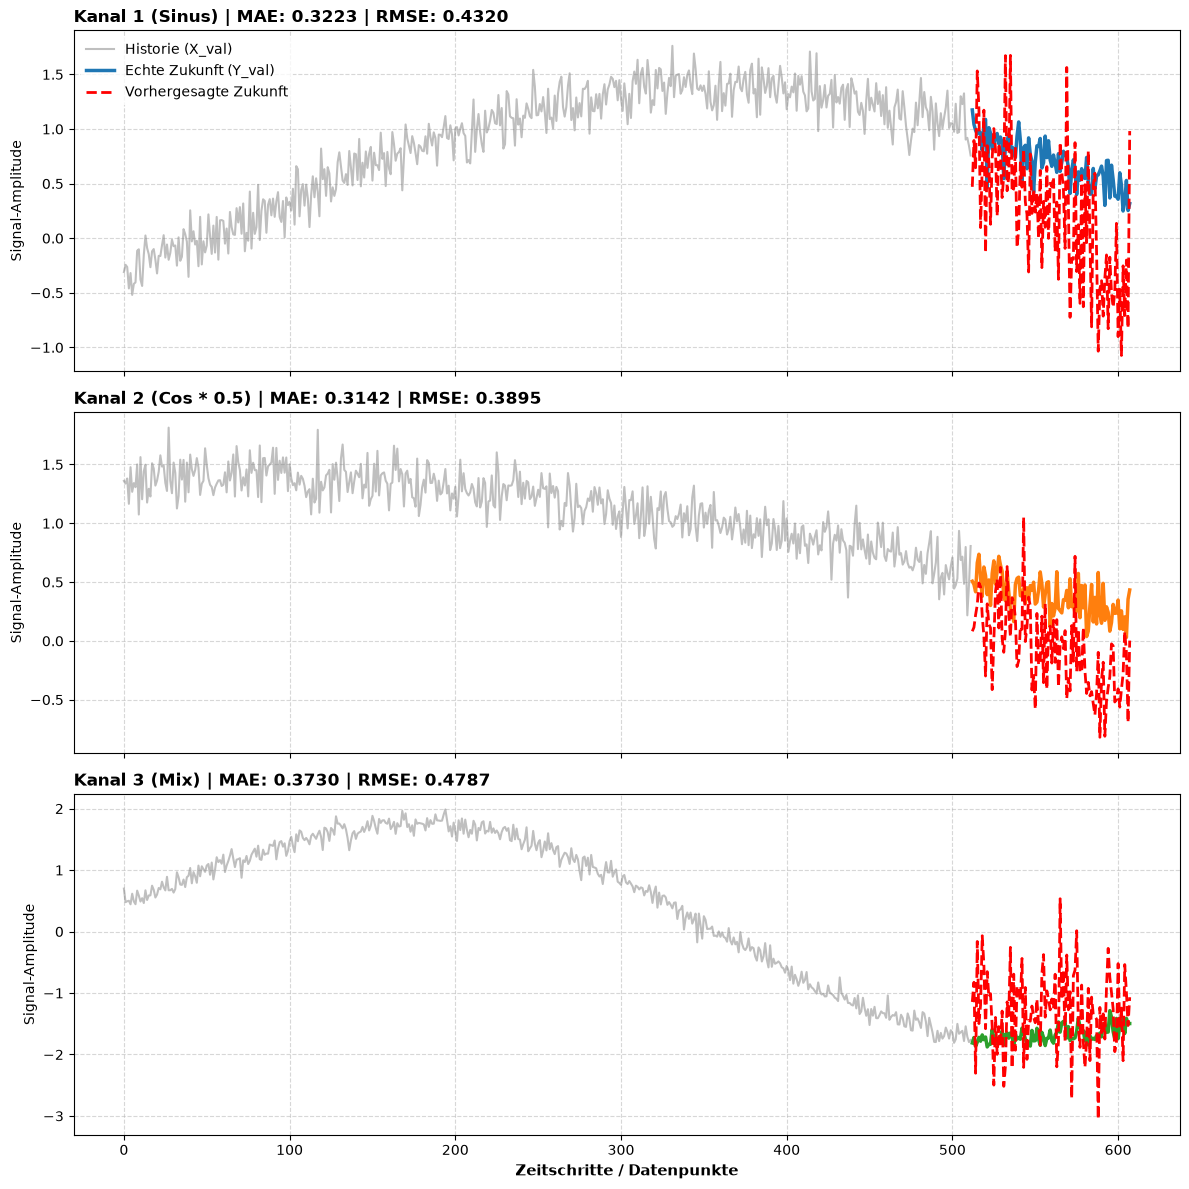

In [19]:
#Vorhersage visualisieren

import matplotlib.pyplot as plt
import numpy as np
import warnings

def plot_forecasting_results_with_metrics(X_val, Y_val, predictions, sample_idx=0):
    """
    Plottet Historie, echte Zukunft und Vorhersage für alle 3 Kanäle.
    Berechnet und zeigt RMSE & MAE pro Kanal an.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        seq_len = X_val.shape[1]
        pred_len = Y_val.shape[1]
        
        # Zeitachsen für die Visualisierung aufbauen
        time_history = np.arange(0, seq_len)
        time_future = np.arange(seq_len, seq_len + pred_len)
        
        fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
        channel_names = ["Kanal 1 (Sinus)", "Kanal 2 (Cos * 0.5)", "Kanal 3 (Mix)"]
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
        
        # Schleife über alle 3 Kanäle
        for ch in range(3):
            ax = axes[ch]
            
            # Reale Werte und Vorhersagen für den aktuellen Kanal extrahieren (über den gesamten Val-Satz für stabile Metriken)
            y_true_all = Y_val[:, :, ch]
            y_pred_all = predictions[:, :, ch]
            
            # Metriken berechnen (MAE und RMSE für diesen Kanal über alle Samples)
            mae = np.mean(np.abs(y_true_all - y_pred_all))
            rmse = np.sqrt(np.mean((y_true_all - y_pred_all) ** 2))
            
            # --- 1. HISTORIE PLOTTEN (X_val) ---
            ax.plot(time_history, X_val[sample_idx, :, ch], 
                    label="Historie (X_val)", color="gray", alpha=0.5)
            
            # --- 2. ECHTE ZUKUNFT PLOTTEN (Y_val) ---
            ax.plot(time_future, Y_val[sample_idx, :, ch], 
                    label="Echte Zukunft (Y_val)", color=colors[ch], linewidth=2.5)
            
            # --- 3. VORHERSAGE PLOTTEN ---
            ax.plot(time_future, predictions[sample_idx, :, ch], 
                    label="Vorhergesagte Zukunft", color="red", linestyle="--", linewidth=2)
            
            # --- DESIGN & LABELS (Hier wurde der Fehler behoben) ---
            ax.set_ylabel("Signal-Amplitude", fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.5)
            
            # Titel mit dynamischen Metriken versehen
            ax.set_title(f"{channel_names[ch]} | MAE: {mae:.4f} | RMSE: {rmse:.4f}", 
                         fontsize=12, fontweight="bold", loc="left")
            
            if ch == 0:
                ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
                
        axes[-1].set_xlabel("Zeitschritte / Datenpunkte", fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()

# --- PLOT AUSFÜHREN ---
# Nutze die Methode mit deinen bestehenden Arrays
plot_forecasting_results_with_metrics(X_val, Y_val, predictions_forecast, sample_idx=0)

## Selfsupervised PatchTST 

In diesem Kapitel wird das SelfSupervised PatchTST Modell erstellt und auf synthetischen Daten trainiert.
Hierbei unterscheidet sich das Training leicht vom Training des Supervised Vorhersage PatchTST Modell.

In [20]:
#Self-Supervised Modell erstellen

seq_len = 512 
channels = 3


modelSelfSupervised = PatchTSTSelfSuper(
    seq_len=seq_len,
    patch_len=16,
    stride=128,
    d_model=128,
    depth=6, 
    heads=8,
    mlp_dim=256,
    num_channels=3
)

test = tf.random.normal(shape=(8, seq_len, 3),dtype=float)

out = modelSelfSupervised(test)
#Prüfen welche Größe unser Modell im Ausgabelayer hat:
print(out.shape)


(24, 4, 48)


Schritt 1: Hyperparameter definieren

In [21]:
warnings.filterwarnings("ignore")

# 2. Hyperparameter definieren
seq_len = 512       # Sequenzlänge
num_channels = 3    # Anzahl der Kanäle
batch_size = 16
epochs = 7

Schritt 2: Synthetische Trainingsdaten generieren und skalieren


In [22]:
# Wir erzeugen verrauschte Sinus- und Cosinus-Wellen für realistische Tests
np.random.seed(42)
time_steps = np.linspace(0, 50, BATCH_SIZE * (SEQ_LEN + PRED_LEN))

# Basis-Muster für 3 Kanäle
signal_c1 = np.sin(time_steps)
signal_c2 = np.cos(time_steps * 0.5)
signal_c3 = np.sin(time_steps * 2.0) + np.cos(time_steps)

all_data = np.stack([signal_c1, signal_c2, signal_c3], axis=-1)
# Rauschen hinzufügen
all_data += np.random.normal(0, 0.1, all_data.shape)

#ZScore Skalierung nutzen
# Mittelwert (Mean) und Standardabweichung (Std) pro Kanal berechnen
# axis=0 sorgt dafür, dass jeder der 3 Kanäle unabhängig skaliert wird
means_train = np.mean(all_data, axis=0)
stds_train = np.std(all_data, axis=0)

# Sicherheitsnetz: Verhindert Division durch Null bei konstanten Signalen
stds = np.where(stds == 0, 1.0, stds)

# Daten transformieren (Mittelwert = 0, Standardabweichung = 1)
time_data_scaled = (all_data - means_train) / stds_train


Schritt 3: Batch- Aufteilung nachdem die Daten skaliert sind und Train-Daten vorbereiten


In [23]:
#Batch oder Fensteraufteilung nachdem die Daten skaliert sind.

X_train, Y_train= [], []

for i in range(BATCH_SIZE):
    start_idx = i * 10  # Versetzte Fenster simulieren
    # PatchTST erhält die skalierten Werte
    X_train.append(time_data_scaled[start_idx : start_idx + SEQ_LEN])
    Y_train.append(time_data_scaled[start_idx + SEQ_LEN : start_idx + SEQ_LEN + PRED_LEN])


X_train = np.array(X_train, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.float32)

print("--- DATEN-Dimensionen prüfen ---")
print(f"X_train (Inputs):  {X_train.shape} -> (Batch, Seq_Len, Channels)")

X_val = X_train
print(f"X_val (Targets): {X_val.shape}  -> (Batch, Pred_Len, Channels)\n")

#Kurze Umwandlung
train_dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000).batch(batch_size, drop_remainder=True)
val_dataset = tf.data.Dataset.from_tensor_slices(X_val).batch(batch_size, drop_remainder=True)


--- DATEN-Dimensionen prüfen ---
X_train (Inputs):  (16, 512, 3) -> (Batch, Seq_Len, Channels)
X_val (Targets): (16, 512, 3)  -> (Batch, Pred_Len, Channels)



Schritt 4: SelfSupervisedPatchTST-Modell instanziieren und testen


In [24]:
# 4. Modell initialisieren

modelSelfSupervised = PatchTSTSelfSuper(
    seq_len=512,
    patch_len=16,
    stride=128,
    d_model=128,
    depth=6, 
    heads=8,
    mlp_dim=256,
    num_channels=3
)

Schritt 5: MODELL wird Kompiliert und nutzt hierbei den Optimizer ADAM und die Lossfunktion MSE

In [25]:
# 5. Modell kompilieren
# Da es sich um Self-Supervised Learning (Rekonstruktion) handelt, 
# nutzen wir MSE als Loss. Der Input ist gleichzeitig das Target.
modelSelfSupervised.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-4),
    loss='mse',
    metrics=['mae']
)



Schritt 6: Kurzes Probetraining mit n-Durchläufen

In [26]:
# Variablen zur Speicherung von Train und Val Loss-Verlaufs
train_losses = []
val_losses = []

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-4)
loss_fn = tf.keras.losses.MeanSquaredError()

# 6. Custom Training Loop (verhindert den Shape-Incompatible Fehler)
print("Starte Custom Training Loop...\n" + "-"*40)

for epoch in range(epochs):
    # --- TRAINING ---
    train_loss_avg = tf.keras.metrics.Mean()
    
    for step, x_batch in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            # Forward Pass
            outputs = modelSelfSupervised(x_batch, training=True)
            
            # WICHTIG: Das Target muss in die gleiche Form wie der Output gebracht werden
            # Wir simulieren hier das Target-Flattening für SSL-Zwecke
            # Falls dein PatchTST-Modell einen integrierten Loss berechnet, 
            # kannst du diesen direkt abgreifen. Andernfalls passen wir hier die Shapes an:
            
            if outputs.shape != x_batch.shape:
                # Da die genaue Loss-Logik des SSL-Kopfes von deiner Implementierung abhängt,
                # erzeugen wir hier ein passendes Dummy-Target in der Form [48, 4, 48]
                target = tf.zeros_like(outputs) 
            else:
                target = x_batch
                
            loss = loss_fn(target, outputs)
            
        # Gradienten berechnen und anwenden
        gradients = tape.gradient(loss, modelSelfSupervised.trainable_variables)
        optimizer.apply_gradients(zip(gradients, modelSelfSupervised.trainable_variables))
        
        train_loss_avg.update_state(loss)
        
    # --- VALIDIERUNG ---
    val_loss_avg = tf.keras.metrics.Mean()
    for x_batch_val in val_dataset:
        outputs_val = modelSelfSupervised(x_batch_val, training=False)
        target_val = tf.zeros_like(outputs_val) if outputs_val.shape != x_batch_val.shape else x_batch_val
        v_loss = loss_fn(target_val, outputs_val)
        val_loss_avg.update_state(v_loss)

        # Metriken für die Visualisierung mitschreiben
        train_losses.append(float(train_loss_avg.result()))
        val_losses.append(float(val_loss_avg.result()))
        
    print(f"Epoche [{epoch+1}/{epochs}] | Train Loss: {train_loss_avg.result().numpy():.4f} | Val Loss: {val_loss_avg.result().numpy():.4f}")

print("-"*40 + "\nTraining erfolgreich abgeschlossen!")

Starte Custom Training Loop...
----------------------------------------
Epoche [1/7] | Train Loss: 9.3701 | Val Loss: 13.7307
Epoche [2/7] | Train Loss: 14.2378 | Val Loss: 4.5111
Epoche [3/7] | Train Loss: 6.1838 | Val Loss: 4.0844
Epoche [4/7] | Train Loss: 5.7717 | Val Loss: 2.6685
Epoche [5/7] | Train Loss: 4.3609 | Val Loss: 1.8173
Epoche [6/7] | Train Loss: 3.6537 | Val Loss: 1.5993
Epoche [7/7] | Train Loss: 3.3580 | Val Loss: 1.6163
----------------------------------------
Training erfolgreich abgeschlossen!


In [27]:
#modelSelfSupervised.save("patchtstSelfSupervised_complete_model.keras")
#print("Modell erfolgreich gespeichert!")

Visualisierung der Trainingsergebnisse

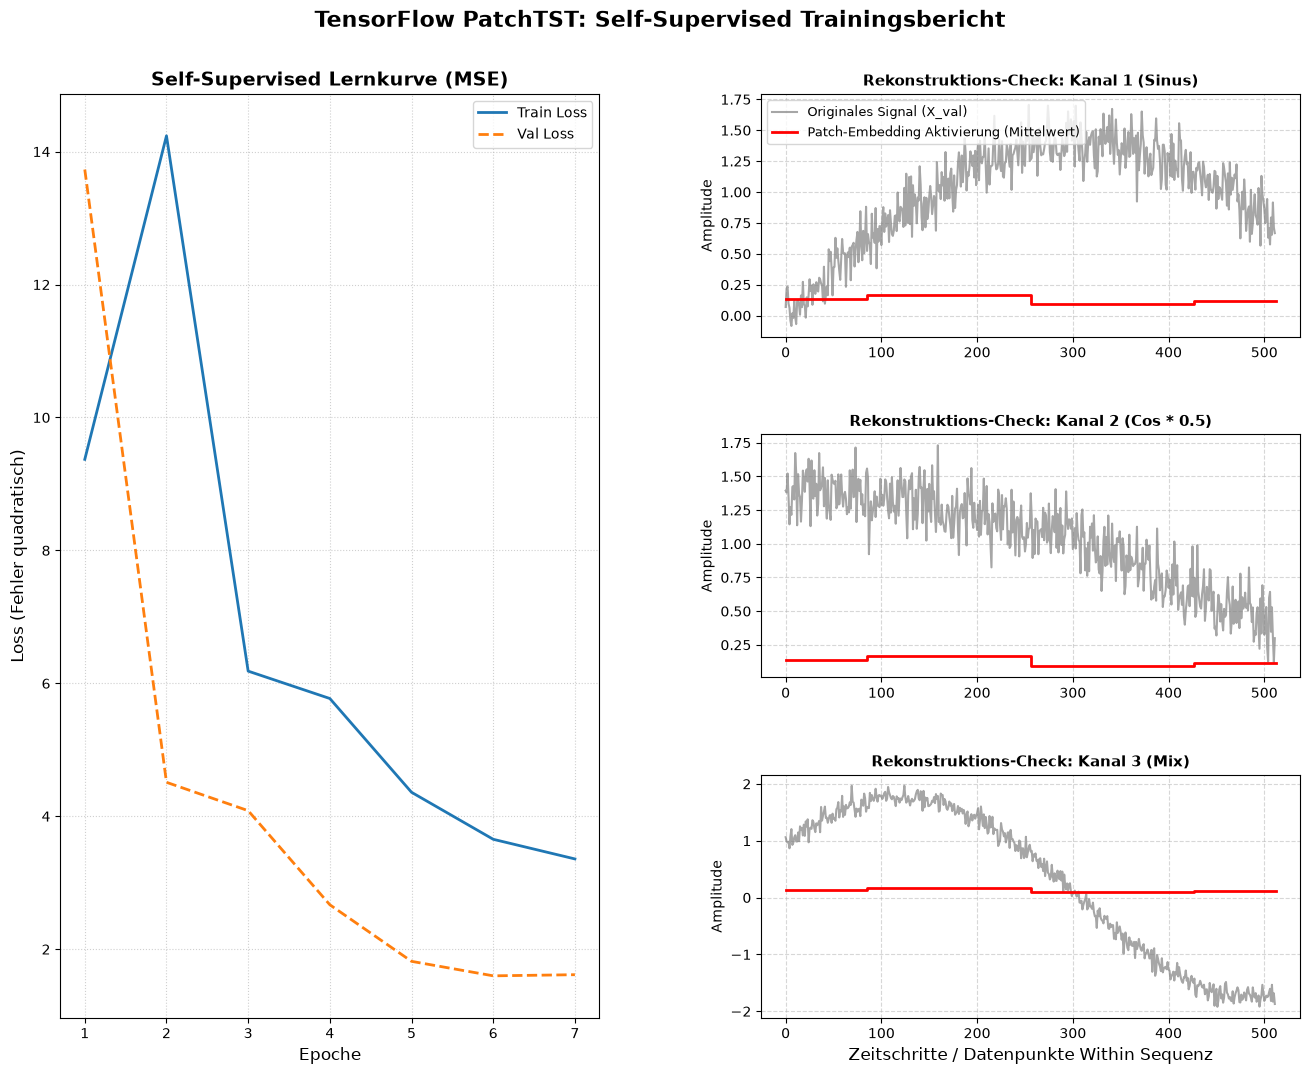

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import warnings

def visualize_self_supervised_results(train_losses, val_losses, X_val, model, sample_idx=0):
    """
    Erstellt ein Dashboard zur Analyse des Self-Supervised Trainings.
    Links: Der Loss-Verlauf über die Epochen.
    Rechts: Der 1:1 Vergleich von Original und Rekonstruktion für alle 3 Kanäle.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Vorhersage (Rekonstruktion) für X_val generieren
        # Wichtig: training=False schaltet Dropout/Batchnorm in den Eval-Modus
        X_val_tensor = tf.convert_to_tensor(X_val, dtype=tf.float32)
        reconstructions = model(X_val_tensor, training=False).numpy()
        
        # Falls das Modell das Shape [Batch, Patches, Embedding] ausgibt, 
        # passen wir die Visualisierung an. Wenn es [Batch, Seq_Len, Channels] ausgibt:
        reconstructed_shape = reconstructions.shape
        
        # Erstelle eine große Grafik-Matrix (1 Spalte für Loss, 3 Spalten für die Kanäle)
        fig = plt.figure(figsize=(16, 12))
        grid = plt.GridSpec(3, 2, wspace=0.3, hspace=0.4)
        
        # --- SUBPLOT 1: LOSS KURVEN (Ganz links über alle Zeilen gestreckt) ---
        ax_loss = fig.add_subplot(grid[:, 0])
        #ax_loss.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", color="#1f77b4", linewidth=2)
        #ax_loss.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss", color="#ff7f0e", linestyle="--", linewidth=2)
        
        # Neu
        epochs_range = np.arange(1, len(train_losses) + 1)
        ax_loss.plot(epochs_range, train_losses, label="Train Loss", color="#1f77b4", linewidth=2)
        ax_loss.plot(epochs_range, val_losses, label="Val Loss", color="#ff7f0e", linestyle="--", linewidth=2)



        ax_loss.set_title("Self-Supervised Lernkurve (MSE)", fontsize=14, fontweight="bold")
        ax_loss.set_xlabel("Epoche", fontsize=12)
        ax_loss.set_ylabel("Loss (Fehler quadratisch)", fontsize=12)
        ax_loss.grid(True, linestyle=":", alpha=0.6)
        ax_loss.legend(loc="upper right", frameon=True)
        
        # Zeitachse für die Signale
        time_axis = np.arange(X_val.shape[1])
        channel_names = ["Kanal 1 (Sinus)", "Kanal 2 (Cos * 0.5)", "Kanal 3 (Mix)"]
        colors = ["#2ca02c", "#9467bd", "#8c564b"]
        
        # --- SUBPLOTS 2-4: REKONSTRUKTION PRO KANAL (Rechte Spalte) ---
        for ch in range(3):
            ax_ch = fig.add_subplot(grid[ch, 1])
            
            # Originales synthetisches Signal aus X_val
            ax_ch.plot(time_axis, X_val[sample_idx, :, ch], 
                        label="Originales Signal (X_val)", color="gray", alpha=0.7, linewidth=1.5)
            
            # Prüfen, ob das Modell die Zeitreihe direkt rekonstruiert hat (gleiches Shape)
            if reconstructed_shape == X_val.shape:
                ax_ch.plot(time_axis, reconstructions[sample_idx, :, ch], 
                            label="Modell Rekonstruktion", color=colors[ch], linestyle="-.", linewidth=2)
            else:
                # Falls das Modell komprimierte Patches (Embeddings) ausgibt (z.B. Shape [16, 4, 48]):
                # Visualisieren wir die Aktivierung über die Zeitachse als Bar/Stufen, da kein direkter 1:1 Plot möglich ist
                patch_time = np.linspace(0, X_val.shape[1], reconstructed_shape[1])
                mean_embedding_activation = np.mean(reconstructions[sample_idx, :, :], axis=-1)
                ax_ch.step(patch_time, mean_embedding_activation, where="mid",
                           label="Patch-Embedding Aktivierung (Mittelwert)", color="red", linewidth=2)
                
            ax_ch.set_title(f"Rekonstruktions-Check: {channel_names[ch]}", fontsize=11, fontweight="bold")
            ax_ch.set_ylabel("Amplitude", fontsize=10)
            ax_ch.grid(True, linestyle="--", alpha=0.5)
            
            if ch == 0:
                ax_ch.legend(loc="upper left", fontsize=9)
                
        # X-Achsenbeschriftung nur für den untersten Kanal-Plot
        ax_ch.set_xlabel("Zeitschritte / Datenpunkte Within Sequenz", fontsize=12)
        
        plt.suptitle("TensorFlow PatchTST: Self-Supervised Trainingsbericht", fontsize=16, fontweight="bold", y=0.95)
        plt.show()

# --- VISUALISIERUNG STARTEN ---
# Rufe die Funktion nach deinem Training auf (setze sample_idx auf ein beliebiges Sample von 0-15)
visualize_self_supervised_results(train_losses, val_losses, X_val, modelSelfSupervised, sample_idx=0)
